1 - fixed acidity\
2 - volatile acidity\
3 - citric acid\
4 - residual sugar\
5 - chlorides\
6 - free sulfur dioxide\
7 - total sulfur dioxide\
8 - density\
9 - pH\
10 - sulphates\
11 - alcohol\
Output variable (based on sensory data):\
12 - quality (score between 0 and 10)

In [1]:
import warnings
warnings.filterwarnings("ignore")

In [546]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from sklearn.experimental import enable_halving_search_cv

from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV, HalvingRandomSearchCV, cross_val_score, learning_curve, validation_curve
from sklearn.preprocessing import StandardScaler, LabelEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report, make_scorer
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.ensemble import StackingClassifier

from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
import xgboost as xgb

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from imblearn.over_sampling import SMOTE

In [24]:
df = pd.read_csv("Wine.csv", index_col="Id", encoding="utf-8")

In [26]:
df

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
Id,,,,,,,,,,,,
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
...,...,...,...,...,...,...,...,...,...,...,...,...
1592,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6
1593,6.8,0.620,0.08,1.9,0.068,28.0,38.0,0.99651,3.42,0.82,9.5,6
1594,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5


In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1088 entries, 0 to 1597
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1088 non-null   float64
 1   volatile acidity      1088 non-null   float64
 2   citric acid           1088 non-null   float64
 3   residual sugar        1088 non-null   float64
 4   chlorides             1088 non-null   float64
 5   free sulfur dioxide   1088 non-null   float64
 6   total sulfur dioxide  1088 non-null   float64
 7   density               1088 non-null   float64
 8   pH                    1088 non-null   float64
 9   sulphates             1088 non-null   float64
 10  alcohol               1088 non-null   float64
 11  quality               1088 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 110.5 KB


In [30]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1088.00000,1088.000000,1088.000000,1088.000000,1088.000000,1088.000000,1088.000000,1088.000000,1088.000000,1088.000000,1088.000000,1088.000000
mean,8.31829,0.525988,0.269375,2.528722,0.086839,15.746783,46.437040,0.996744,3.309338,0.657307,10.429764,5.687500
std,1.74193,0.172482,0.194473,1.361514,0.045385,10.257763,32.997037,0.001921,0.153479,0.165827,1.067342,0.691485
min,4.90000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.860000,0.390000,8.400000,5.000000
25%,7.10000,0.390000,0.100000,1.900000,0.070000,7.000000,22.000000,0.995595,3.200000,0.550000,9.500000,5.000000
50%,7.90000,0.520000,0.250000,2.200000,0.079000,14.000000,38.000000,0.996700,3.310000,0.620000,10.200000,6.000000
75%,9.10000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997860,3.400000,0.730000,11.100000,6.000000
max,15.90000,1.330000,0.790000,15.500000,0.611000,68.000000,289.000000,1.003690,4.010000,1.950000,14.900000,7.000000


In [32]:
df.isnull().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

## EDA

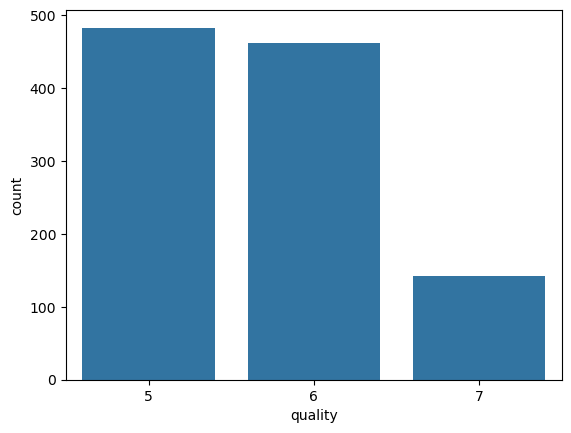

In [35]:
sns.countplot(x="quality", data=df)
plt.show()

По графику видим, что классы не сбалансированны

<Figure size 1200x600 with 0 Axes>

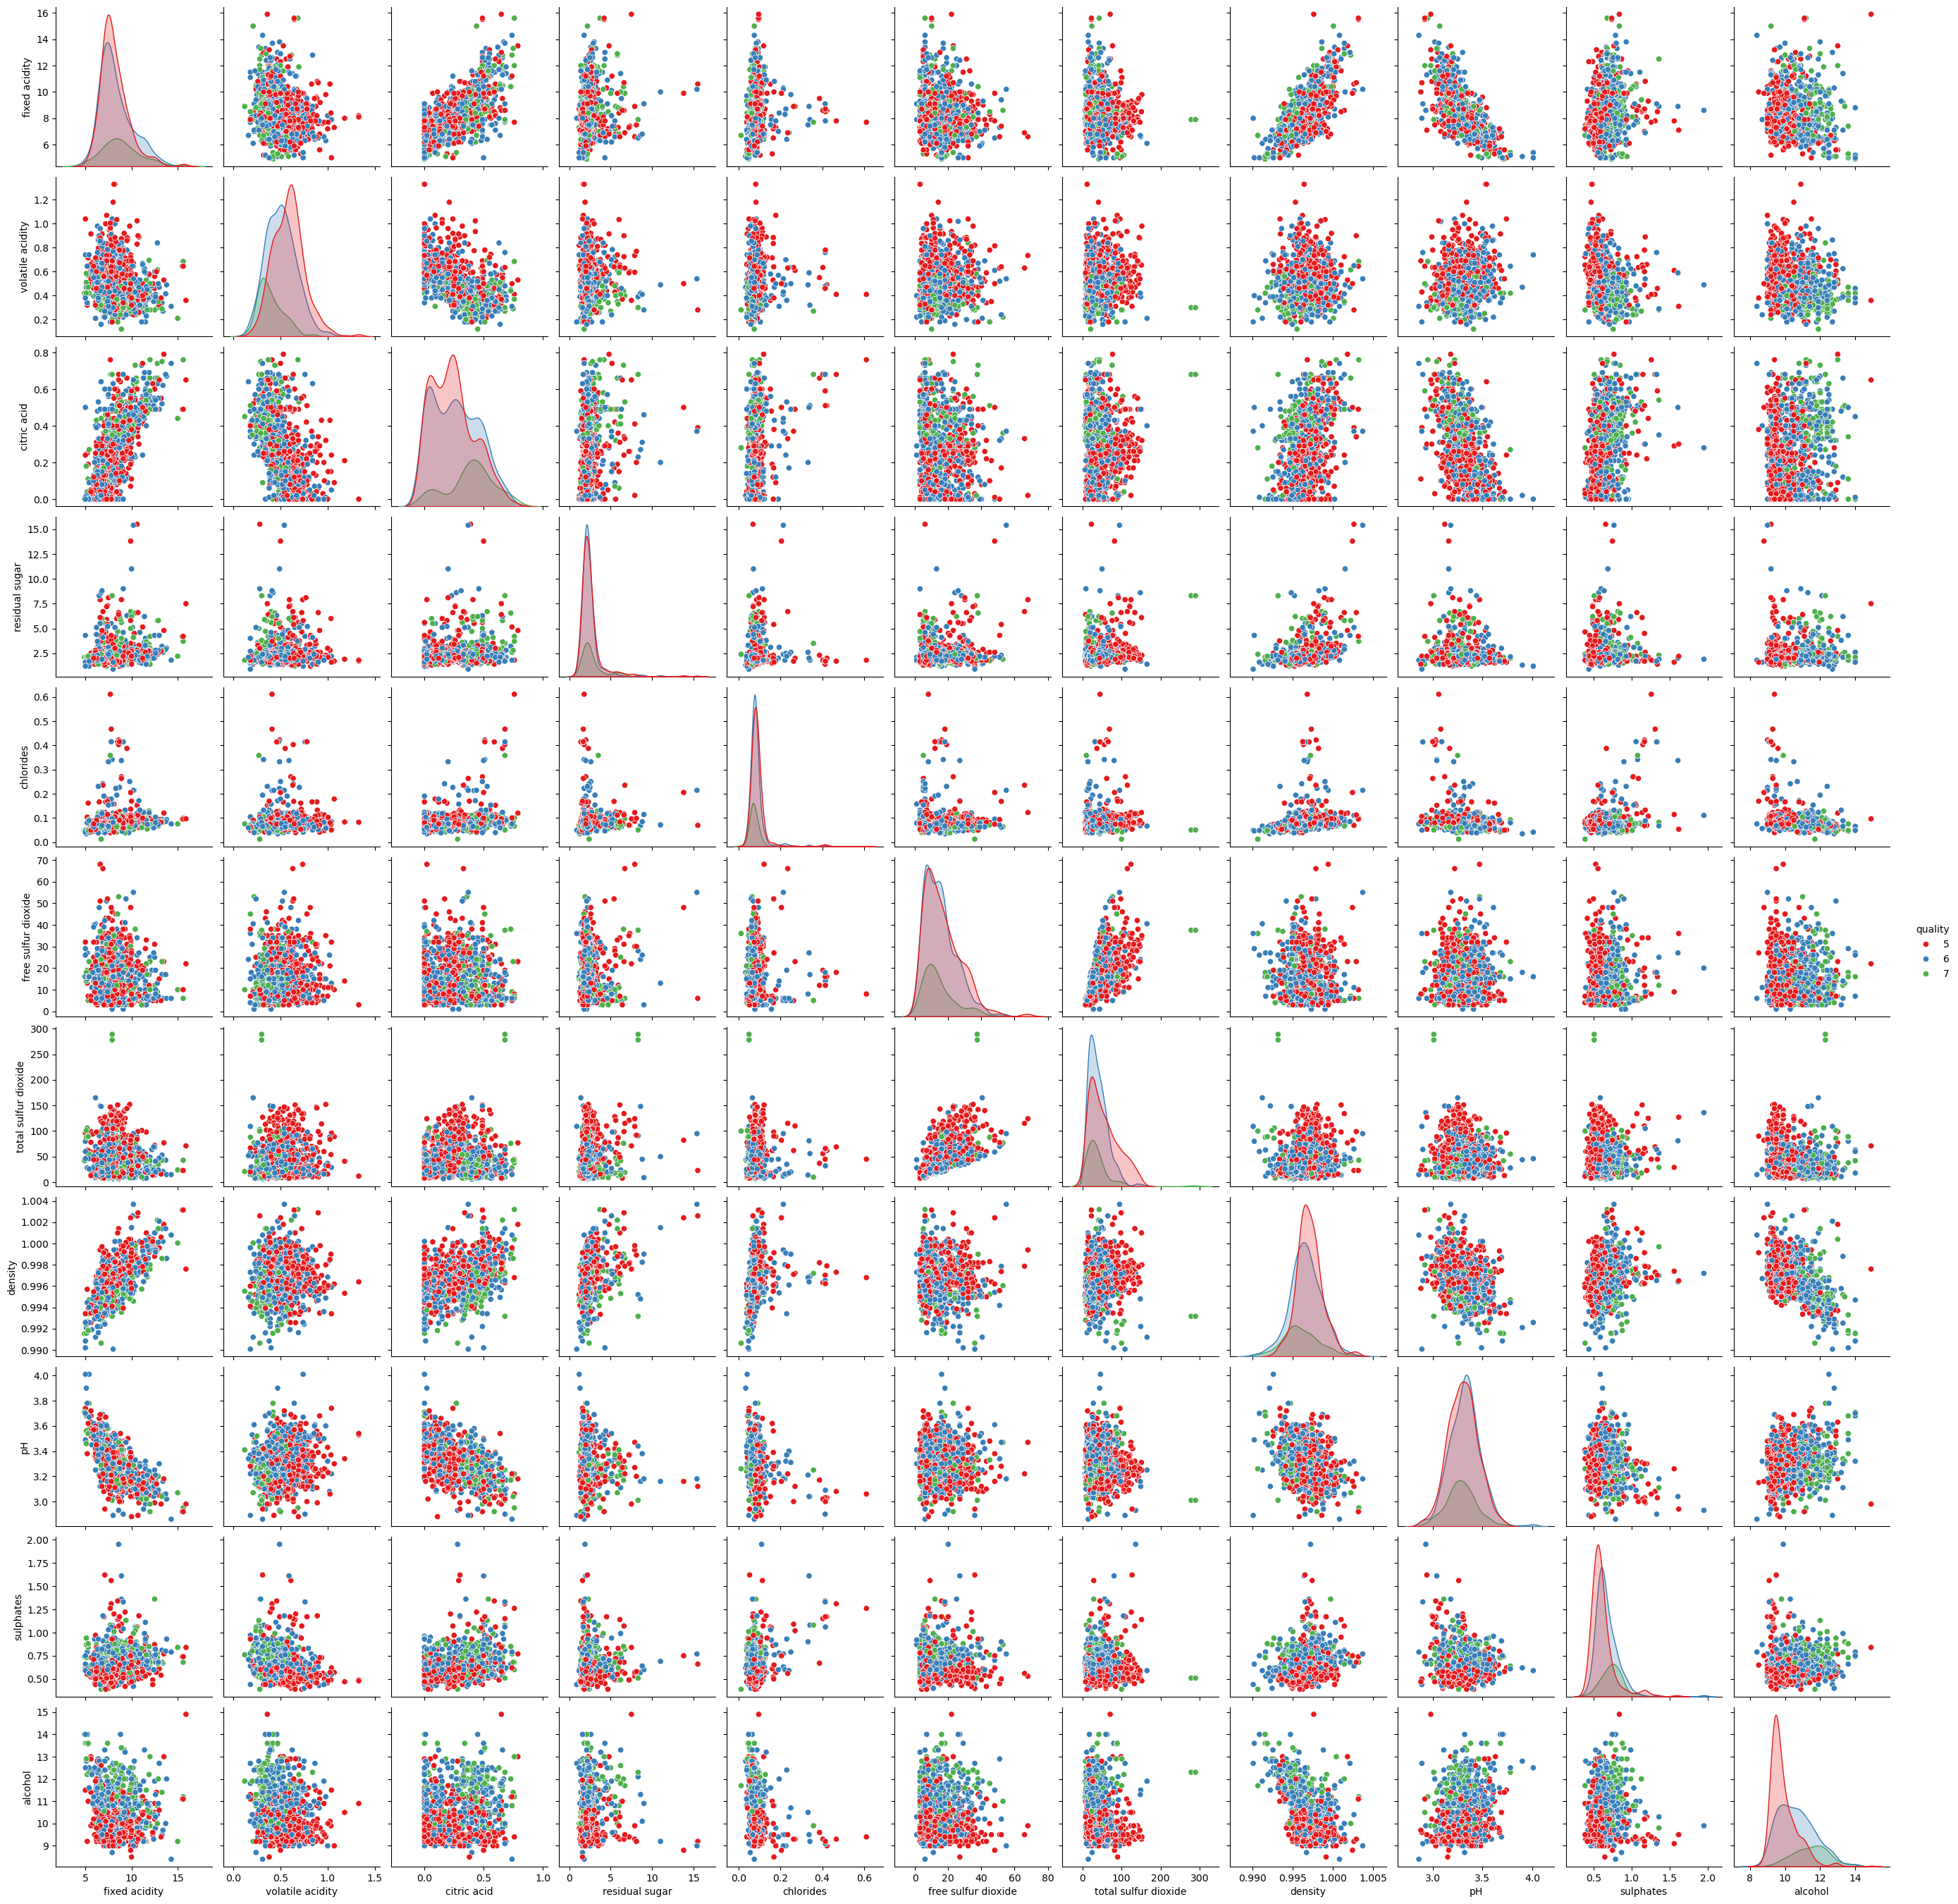

In [38]:
plt.figure(figsize=(12, 6))
sns.pairplot(df, hue="quality", palette="Set1")
plt.show()

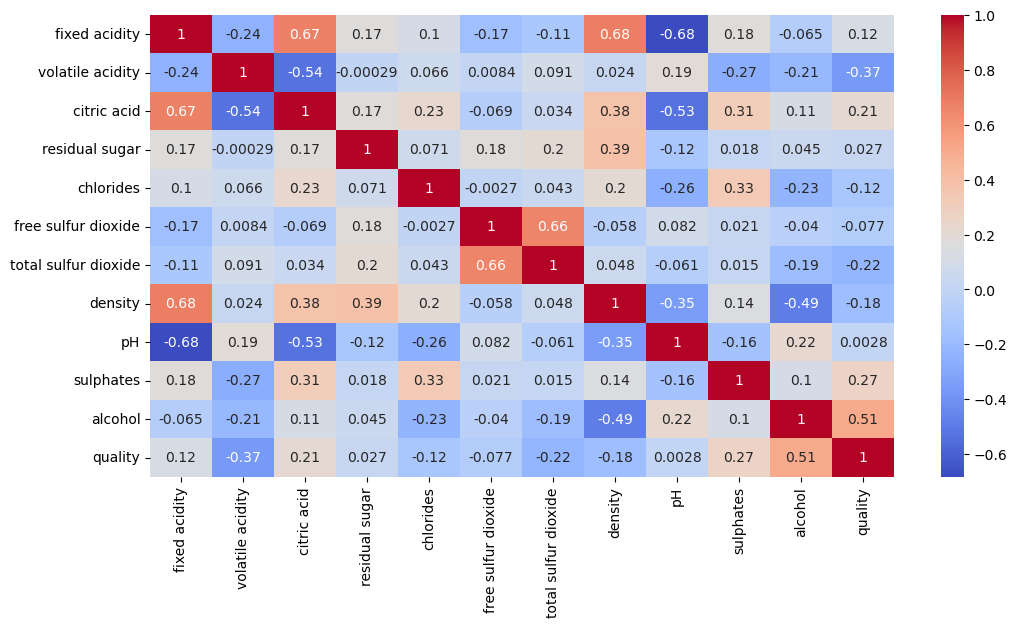

In [39]:
plt.figure(figsize=(12, 6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.show()

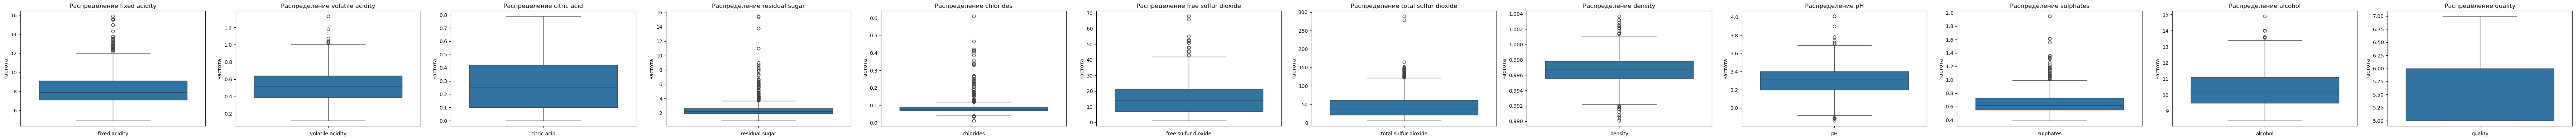

In [40]:
num_cols = df.select_dtypes(include=['float', 'int']).columns 
fig, axes = plt.subplots(1, len(num_cols), figsize=(6 * len(num_cols), 4))

for ax, col in zip(axes, num_cols):
   sns.boxplot(df[col], ax=ax)
   ax.set_title(f'Распределение {col}')
   ax.set_xlabel(col)
   ax.set_ylabel('Частота')

plt.tight_layout()
plt.show()

In [41]:
df.duplicated().sum()

124

### Применим lda для анализа сжатых данныъ

In [52]:
X_train_lda.shape

(761, 11)

In [58]:
X_lda = df.drop(["quality"], axis=1)
y_lda = df["quality"]

sc = StandardScaler()
X_lda_std = sc.fit_transform(X_lda)

X_train_lda, X_test_lda, y_train_lda, y_test_lda = train_test_split(X_lda_std, y_lda, test_size=0.3, random_state=42, stratify=y_lda)

lda_2d = LDA(n_components=2)
df_lda_2d= lda_2d.fit_transform(X_train_lda, y_train_lda)

pca_3d = PCA(n_components=3, random_state=1)
df_pca_3d = pca_3d.fit_transform(X_train_lda)

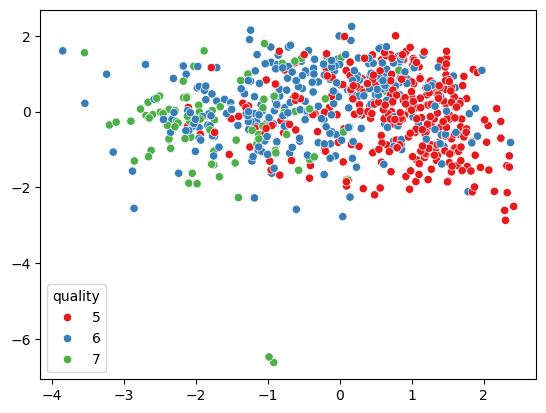

In [60]:
sns.scatterplot(x=df_lda_2d[:, 0], y=df_lda_2d[:, 1], hue=y_train_lda, palette="Set1")
plt.show()

Выделим, что сжатые в 2D данные не поддаются описанию. Их невозможно разделить линейно

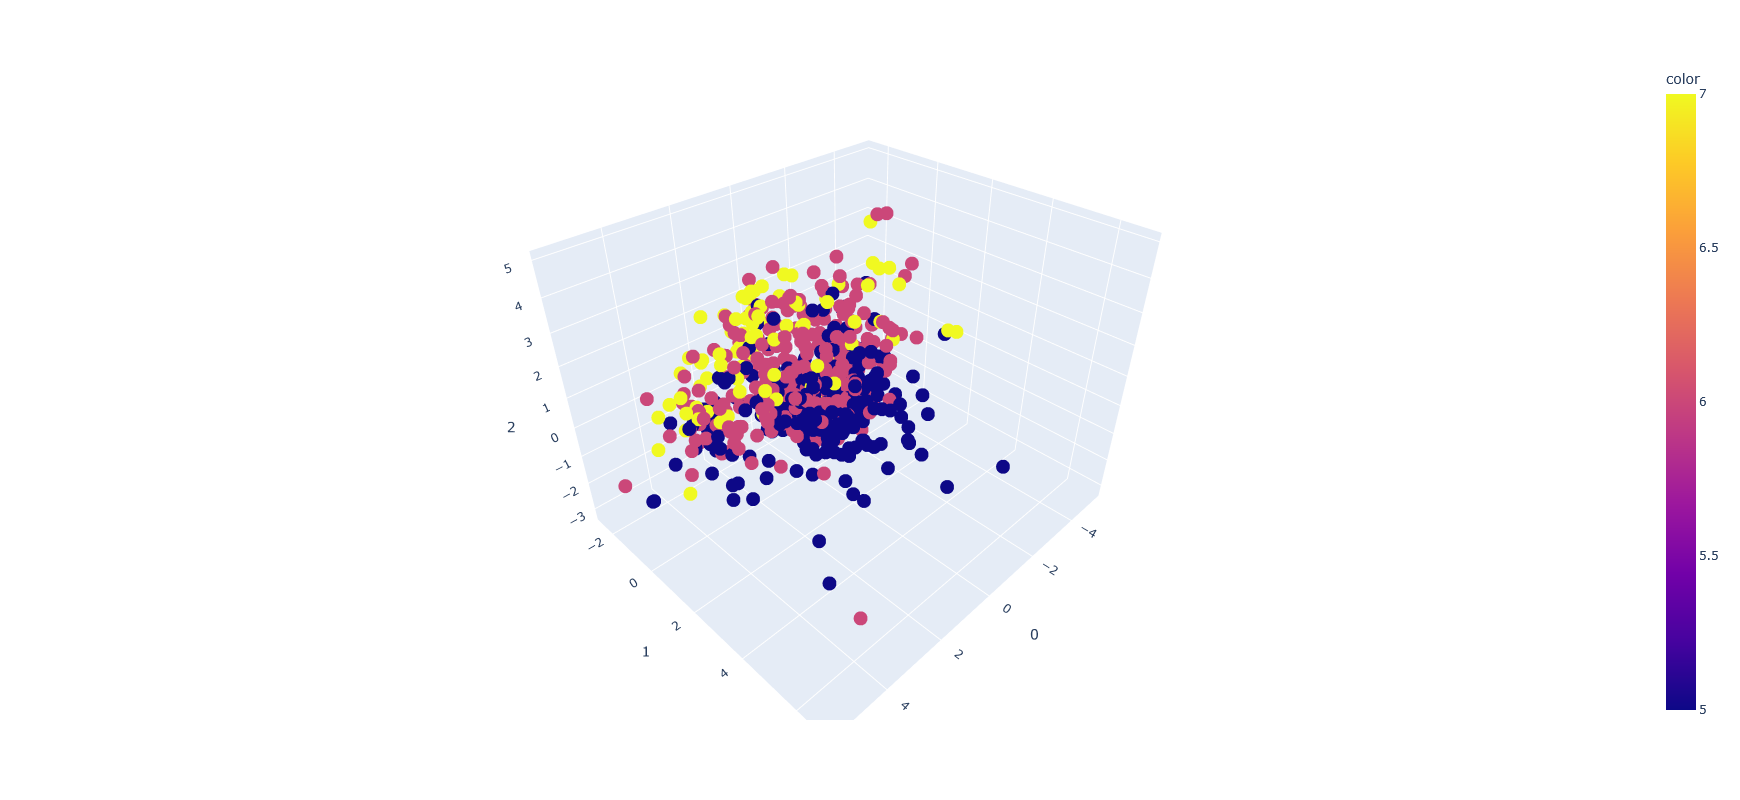

In [285]:
fig = px.scatter_3d(df_pca_3d, x=0, y=1, z=2, color=y_train_lda,
                   width=1000,  
                   height=800)    
fig.show()

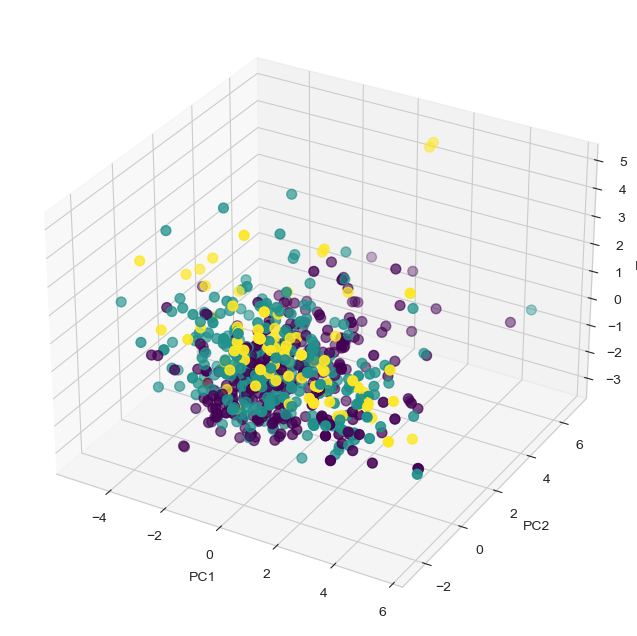

In [84]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(df_pca_3d[:, 0], df_pca_3d[:, 1], df_pca_3d[:, 2], 
           c=y_train_lda.astype(int), cmap='viridis', s=50)

ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')
plt.show()

С данными в 3D пространстве также, не представляется увидеть разделения в виде гиперплоскости

### Посмотрим на важные признаки нашего набора

In [160]:
lr = LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=1000)

sfs_lr = SequentialFeatureSelector(
    estimator=lr,
    n_features_to_select=8,     
    direction='backward',        
    cv=5,                       
    n_jobs=-1                   
)

sfs_lr.fit(X_train_lda, y_train_lda)

print(df.columns)
print("Выбранные признаки:", sfs_lr.get_support())
print("Количество:", sfs_lr.n_features_to_select_)
print("X_train.shape:", sfs_lr.transform(X_train).shape)

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality'],
      dtype='object')
Выбранные признаки: [ True  True  True False  True  True False  True False  True  True]
Количество: 8
X_train.shape: (800, 8)


In [161]:
knn = KNeighborsClassifier()

sfs_knn = SequentialFeatureSelector(
    estimator=knn,
    n_features_to_select=8,     
    direction='backward',        
    cv=5,                       
    n_jobs=-1                   
)

sfs_knn.fit(X_train_lda, y_train_lda)

print(df.columns)
print("Выбранные признаки:", sfs_knn.get_support())
print("Количество:", sfs_knn.n_features_to_select_)
print("X_train.shape:", sfs_knn.transform(X_train).shape)

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality'],
      dtype='object')
Выбранные признаки: [False  True  True False  True  True  True  True False  True  True]
Количество: 8
X_train.shape: (800, 8)


Видим, что признаки `residual sugar` и `sulphates` для обоих моделей имеют наименьшую значимость

In [88]:
df = df.drop(["residual sugar", "sulphates"], axis=1)

In [90]:
df.shape

(1088, 10)

Удалили эти признаки

### SMOTE - создаем искусственный баланс классов

In [119]:
X = df.drop(["quality"], axis=1)
y = df["quality"]

X_std = sc.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_std, y, test_size=0.3, random_state=42, stratify=y)

In [121]:
(X_train.shape, X_test.shape)

((761, 9), (327, 9))

In [123]:
(y_train.shape, y_test.shape)

((761,), (327,))

In [137]:
np.bincount(y_test)

array([  0,   0,   0,   0,   0, 145, 139,  43], dtype=int64)

In [139]:
np.bincount(y_train)

array([  0,   0,   0,   0,   0, 338, 323, 100], dtype=int64)

In [131]:
smote = SMOTE(random_state=42)
X_train_resampl, y_train_resampl = smote.fit_resample(X_train, y_train)

In [133]:
np.bincount(y_train_resampl)

array([  0,   0,   0,   0,   0, 338, 338, 338], dtype=int64)

In [144]:
(X_train_resampl.shape, y_train_resampl.shape)

((1014, 9), (1014,))

Сбалансировали данные 

## BaseLine

In [146]:
Prange = np.linspace(0, 100, 500)

param_grid = [{
    "C": Prange,
    "penalty": ["l1", "l2", "elasticnet"],
    "class_weight": ["balanced"],
    "solver": ["lbfgs", "liblinear", "newton-cg", "newton-cholesky", "sag", "saga"], 
    "multi_class": ["multinomial"]
}]

In [184]:
lr_ovr = LogisticRegression()

hs = HalvingRandomSearchCV(
    lr_ovr,
    param_distributions=param_grid,
    n_candidates='exhaust',
    resource='n_samples',
    factor=1.5,
    random_state=1,
    n_jobs=-1
)

hs.fit(X_train_resampl, y_train_resampl)

print(hs.best_score_)
print(hs.best_params_)

0.6256793945648436
{'solver': 'saga', 'penalty': 'l1', 'multi_class': 'multinomial', 'class_weight': 'balanced', 'C': 10.02004008016032}


In [308]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=1)

lr = hs.best_estimator_

f1_weighted = make_scorer(f1_score, average='weighted', zero_division=0)
scores = cross_val_score(lr, X_train_resampl, y_train_resampl_encoded, cv=skf, scoring=f1_weighted, error_score='raise')
scores

array([0.62368584, 0.59388914, 0.64335852, 0.59637135, 0.64260723])

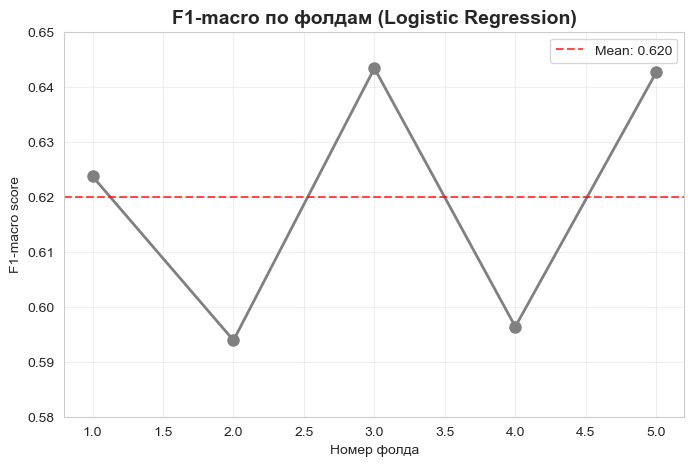

In [320]:
folds = np.arange(1, 6)

plt.figure(figsize=(8, 5))
plt.plot(folds, scores, marker='o', linewidth=2, markersize=8, color='gray')
plt.axhline(y=np.mean(scores), color='red', linestyle='--', alpha=0.7, label=f'Mean: {np.mean(scores):.3f}')

plt.title('F1-macro по фолдам (Logistic Regression)', fontsize=14, fontweight='bold')
plt.xlabel('Номер фолда')
plt.ylabel('F1-macro score')
plt.ylim(0.58, 0.65)
plt.grid(True, alpha=0.3)
plt.legend()

In [316]:
train_score_baseline = lr.score(X_train_resampl, y_train_resampl)
test_score_baseline = lr.score(X_test, y_test)

(round(train_score_baseline, 3), round(test_score_baseline, 3))

(0.653, 0.55)

Видим недообученние модели

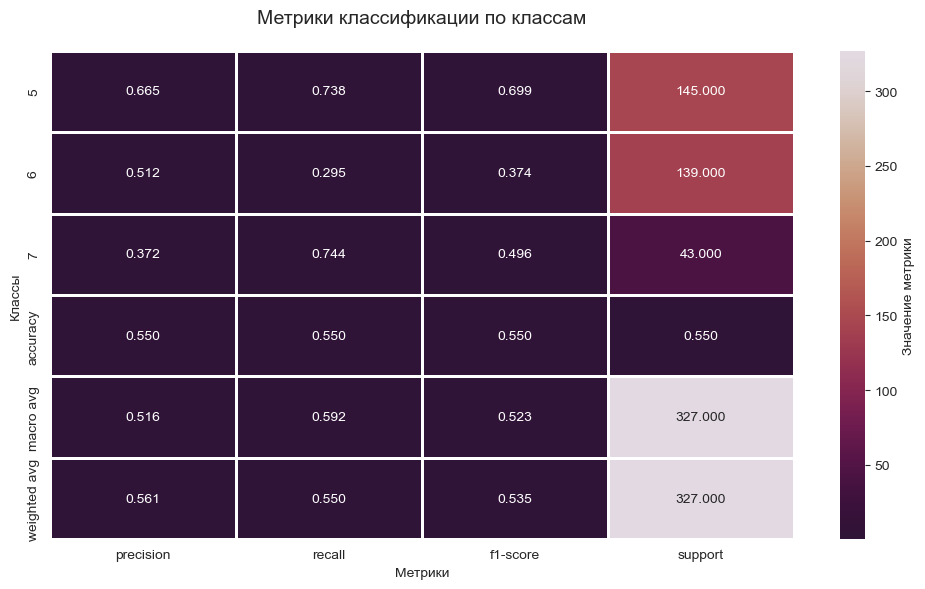

In [154]:
y_pred_dtc = lr.predict(X_test)

report_dict = classification_report(y_test, y_pred_dtc, output_dict=True)
metrics_df = pd.DataFrame(report_dict).transpose()

plt.figure(figsize=(10, 6))
sns.heatmap(metrics_df, 
            annot=True, 
            fmt='.3f', 
            cmap='twilight',
            center=0.5,
            linewidths=1,
            cbar_kws={'label': 'Значение метрики'})

plt.title('Метрики классификации по классам', fontsize=14, pad=20)
plt.xlabel('Метрики')
plt.ylabel('Классы')
plt.tight_layout()
plt.show()

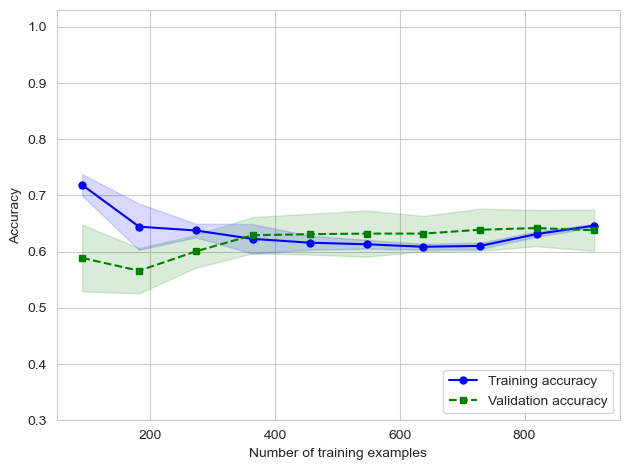

In [313]:
train_sizes, train_scores, test_scores =\
                learning_curve(estimator=lr,
                               X=X_train_resampl,
                               y=y_train_resampl,
                               train_sizes=np.linspace(0.1, 1.0, 10),
                               cv=10,
                               n_jobs=-1)

train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

plt.plot(train_sizes, train_mean,
         color='blue', marker='o',
         markersize=5, label='Training accuracy')

plt.fill_between(train_sizes,
                 train_mean + train_std,
                 train_mean - train_std,
                 alpha=0.15, color='blue')

plt.plot(train_sizes, test_mean,
         color='green', linestyle='--',
         marker='s', markersize=5,
         label='Validation accuracy')

plt.fill_between(train_sizes,
                 test_mean + test_std,
                 test_mean - test_std,
                 alpha=0.15, color='green')

plt.grid()
plt.xlabel('Number of training examples')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.ylim([0.3, 1.03])
plt.tight_layout()
plt.show()

Видим систематическая ошибка (смещение). 

Модель слишком проста, чтобы уловить закономерности.

# Model - Улучшаем baseline

## KNN

In [190]:
param_grid_knn = [{
    "n_neighbors": [2, 3, 4, 5, 6, 7, 8, 9, 10],
    "weights": ["uniform", "distance"],
    "algorithm": ["auto", "ball_tree", "kd_tree", "brute"],
    "metric": ["minkowski", "cosine", "euclidean", "haversine", "l1", "l2", "manhattan"], 
    "leaf_size": np.arange(30, 150),
    "p": np.arange(2, 50)
}]

knn = KNeighborsClassifier()

hs_knn = HalvingRandomSearchCV(
    knn,
    param_distributions=param_grid_knn,
    n_candidates='exhaust',
    resource='n_samples',
    factor=1.5,
    random_state=1,
    n_jobs=-1
)

hs_knn.fit(X_train_resampl, y_train_resampl)

print(hs_knn.best_score_)
print(hs_knn.best_params_)

knn_best = hs_knn.best_estimator_

0.7028723770209837
{'weights': 'distance', 'p': 17, 'n_neighbors': 7, 'metric': 'cosine', 'leaf_size': 111, 'algorithm': 'auto'}


In [324]:
scores_knn = cross_val_score(knn_best, X_train_resampl, y_train_resampl_encoded, cv=skf, scoring=f1_weighted, error_score='raise')
scores_knn

array([0.7143586 , 0.70303237, 0.65464662, 0.73789586, 0.71135321])

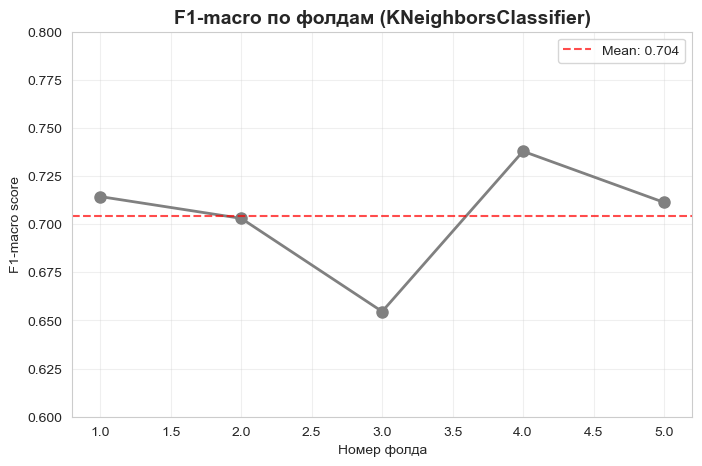

In [401]:
folds = np.arange(1, 6)

plt.figure(figsize=(8, 5))
plt.plot(folds, scores_knn, marker='o', linewidth=2, markersize=8, color='gray')
plt.axhline(y=np.mean(scores_knn), color='red', linestyle='--', alpha=0.7, label=f'Mean: {np.mean(scores_knn):.3f}')

plt.title('F1-macro по фолдам (KNeighborsClassifier)', fontsize=14, fontweight='bold')
plt.xlabel('Номер фолда')
plt.ylabel('F1-macro score')
plt.ylim(0.6, 0.8)
plt.grid(True, alpha=0.3)
plt.legend()

In [339]:
train_score_knn_best = knn_best.score(X_train_resampl, y_train_resampl)
test_score_knn_best = knn_best.score(X_test, y_test)

(round(train_score_knn_best, 3), round(test_score_knn_best, 3))

(1.0, 0.633)

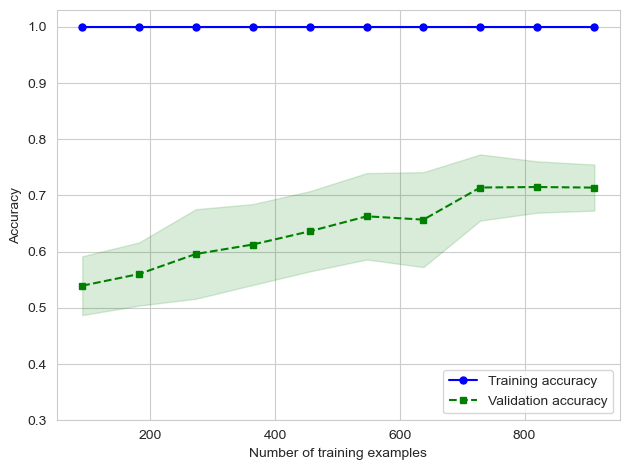

In [342]:
train_sizes, train_scores, test_scores =\
                learning_curve(estimator=knn_best,
                               X=X_train_resampl,
                               y=y_train_resampl,
                               train_sizes=np.linspace(0.1, 1.0, 10),
                               cv=10,
                               n_jobs=-1)

train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

plt.plot(train_sizes, train_mean,
         color='blue', marker='o',
         markersize=5, label='Training accuracy')

plt.fill_between(train_sizes,
                 train_mean + train_std,
                 train_mean - train_std,
                 alpha=0.15, color='blue')

plt.plot(train_sizes, test_mean,
         color='green', linestyle='--',
         marker='s', markersize=5,
         label='Validation accuracy')

plt.fill_between(train_sizes,
                 test_mean + test_std,
                 test_mean - test_std,
                 alpha=0.15, color='green')

plt.grid()
plt.xlabel('Number of training examples')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.ylim([0.3, 1.03])
plt.tight_layout()
plt.show()

KNN демонстрирует нам высокую дисперсию. Модель переобучилась, хорошо разделяет train, но плохо обобщает. 

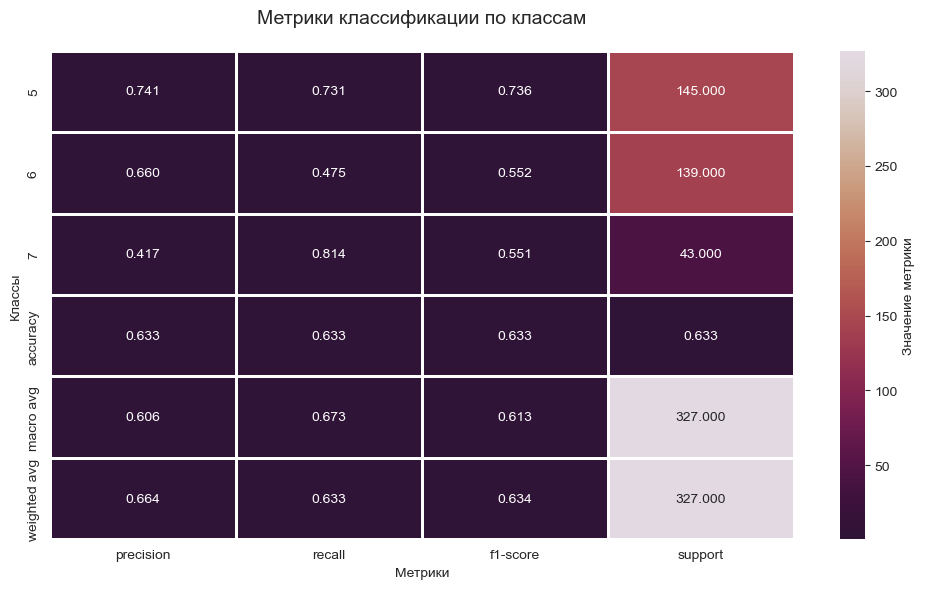

In [348]:
y_pred_knn_best = knn_best.predict(X_test)

report_dict = classification_report(y_test, y_pred_knn_best, output_dict=True)
metrics_df = pd.DataFrame(report_dict).transpose()

plt.figure(figsize=(10, 6))
sns.heatmap(metrics_df, 
            annot=True, 
            fmt='.3f', 
            cmap='twilight',
            center=0.5,
            linewidths=1,
            cbar_kws={'label': 'Значение метрики'})

plt.title('Метрики классификации по классам', fontsize=14, pad=20)
plt.xlabel('Метрики')
plt.ylabel('Классы')
plt.tight_layout()
plt.show()

## SVM

In [279]:
param_grid_svc = [{
    "C": Prange,
    "kernel": ["rbf"],
    "degree": np.arange(2, 100),
    "coef0": np.arange(5, 100),
    "cache_size": np.arange(200, 1000, 100), 
    "class_weight": ["balanced"],
    "decision_function_shape": ["ovr"]
}]

svc = SVC()

hs_svc = HalvingRandomSearchCV(
    svc,
    param_distributions=param_grid_svc,
    n_candidates='exhaust',
    resource='n_samples',
    factor=1.5,
    random_state=1,
    n_jobs=-1
)

hs_svc.fit(X_train_resampl, y_train_resampl)

print(hs_svc.best_score_)
print(hs_svc.best_params_)

svc_best = hs_svc.best_estimator_

0.6989508083935327
{'kernel': 'rbf', 'degree': 4, 'decision_function_shape': 'ovr', 'coef0': 62, 'class_weight': 'balanced', 'cache_size': 500, 'C': 36.47294589178357}


In [351]:
scores_svc_best = cross_val_score(svc_best, X_train_resampl, y_train_resampl_encoded, cv=skf, scoring=f1_weighted, error_score='raise')
scores_svc_best

array([0.72700261, 0.72503301, 0.72771185, 0.72364088, 0.75122893])

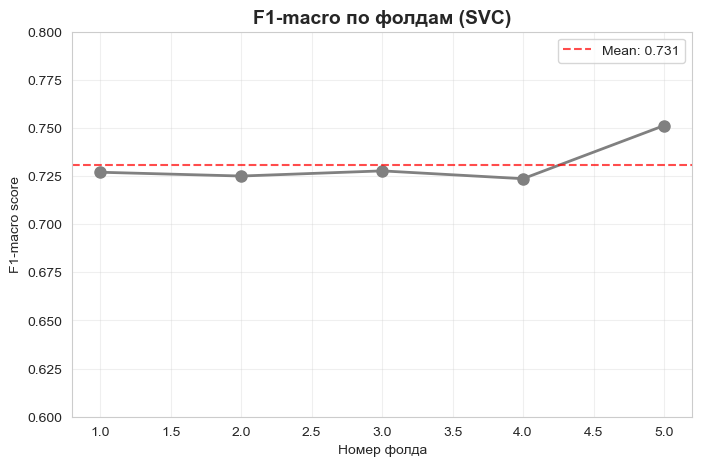

In [399]:
folds = np.arange(1, 6)

plt.figure(figsize=(8, 5))
plt.plot(folds, scores_svc_best, marker='o', linewidth=2, markersize=8, color='gray')
plt.axhline(y=np.mean(scores_svc_best), color='red', linestyle='--', alpha=0.7, label=f'Mean: {np.mean(scores_svc_best):.3f}')

plt.title('F1-macro по фолдам (SVC)', fontsize=14, fontweight='bold')
plt.xlabel('Номер фолда')
plt.ylabel('F1-macro score')
plt.ylim(0.6, 0.8)
plt.grid(True, alpha=0.3)
plt.legend()

In [355]:
train_score_svc_best = svc_best.score(X_train_resampl, y_train_resampl)
test_score_svc_best = svc_best.score(X_test, y_test)

(round(train_score_svc_best, 3), round(test_score_svc_best, 3))

(0.886, 0.572)

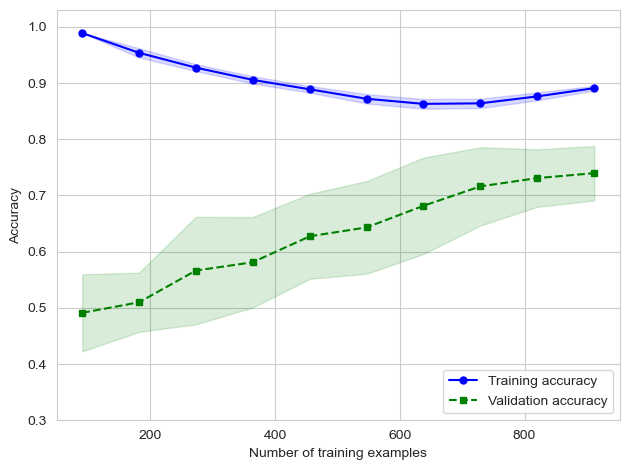

In [357]:
train_sizes, train_scores, test_scores =\
                learning_curve(estimator=svc_best,
                               X=X_train_resampl,
                               y=y_train_resampl,
                               train_sizes=np.linspace(0.1, 1.0, 10),
                               cv=10,
                               n_jobs=-1)

train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

plt.plot(train_sizes, train_mean,
         color='blue', marker='o',
         markersize=5, label='Training accuracy')

plt.fill_between(train_sizes,
                 train_mean + train_std,
                 train_mean - train_std,
                 alpha=0.15, color='blue')

plt.plot(train_sizes, test_mean,
         color='green', linestyle='--',
         marker='s', markersize=5,
         label='Validation accuracy')

plt.fill_between(train_sizes,
                 test_mean + test_std,
                 test_mean - test_std,
                 alpha=0.15, color='green')

plt.grid()
plt.xlabel('Number of training examples')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.ylim([0.3, 1.03])
plt.tight_layout()
plt.show()

SVC также показавыет overfitting

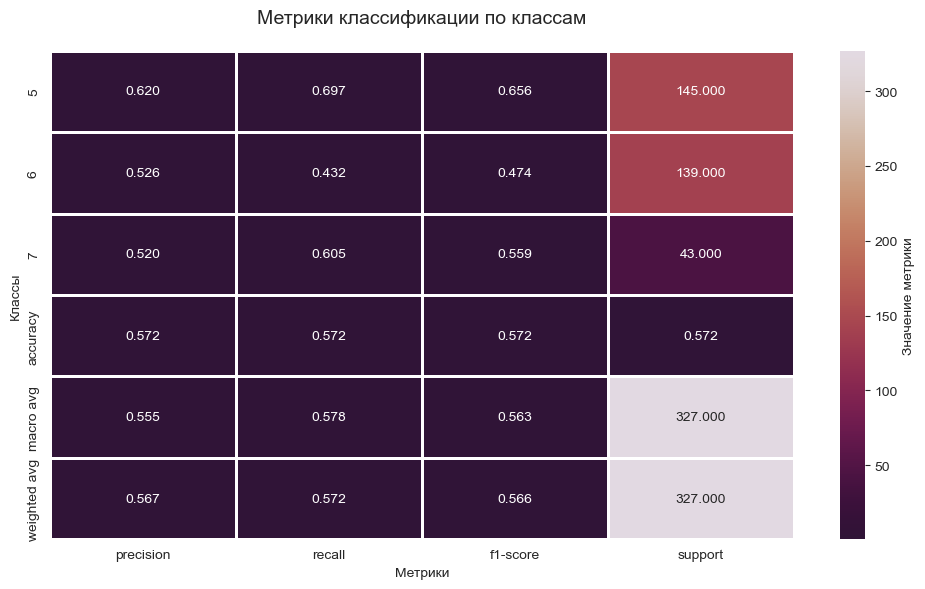

In [359]:
y_pred_svc_best = svc_best.predict(X_test)

report_dict = classification_report(y_test, y_pred_svc_best, output_dict=True)
metrics_df = pd.DataFrame(report_dict).transpose()

plt.figure(figsize=(10, 6))
sns.heatmap(metrics_df, 
            annot=True, 
            fmt='.3f', 
            cmap='twilight',
            center=0.5,
            linewidths=1,
            cbar_kws={'label': 'Значение метрики'})

plt.title('Метрики классификации по классам', fontsize=14, pad=20)
plt.xlabel('Метрики')
plt.ylabel('Классы')
plt.tight_layout()
plt.show()

## Мажоритарное голосование

In [534]:
voting_clf = VotingClassifier(
    estimators=[    
        ('lr', lr),
        ('knn', knn_best),
        ('svc', svc_best)
    ],
    weights=[0.2, 0.5, 0.3],
    voting='hard'       
)

voting_clf.fit(X_train_resampl, y_train_resampl)

VotingClassifier(estimators=[('lr',
                              LogisticRegression(C=10.02004008016032,
                                                 class_weight='balanced',
                                                 multi_class='multinomial',
                                                 penalty='l1', solver='saga')),
                             ('knn',
                              KNeighborsClassifier(leaf_size=111,
                                                   metric='cosine',
                                                   n_neighbors=7, p=17,
                                                   weights='distance')),
                             ('svc',
                              SVC(C=36.47294589178357, cache_size=500,
                                  class_weight='balanced', coef0=62,
                                  degree=4))],
                 weights=[0.2, 0.5, 0.3])

In [536]:
train_score_vot = voting_clf.score(X_train_resampl, y_train_resampl)
test_score_vot = voting_clf.score(X_test, y_test)

(round(train_score_vot, 2), round(test_score_vot, 2))

(0.95, 0.62)

In [458]:
scores_vot = cross_val_score(voting_clf, X_train_resampl, y_train_resampl_encoded, cv=skf, scoring=f1_weighted, error_score='raise')
scores_vot

array([0.7143586 , 0.70303237, 0.65464662, 0.73789586, 0.71135321])

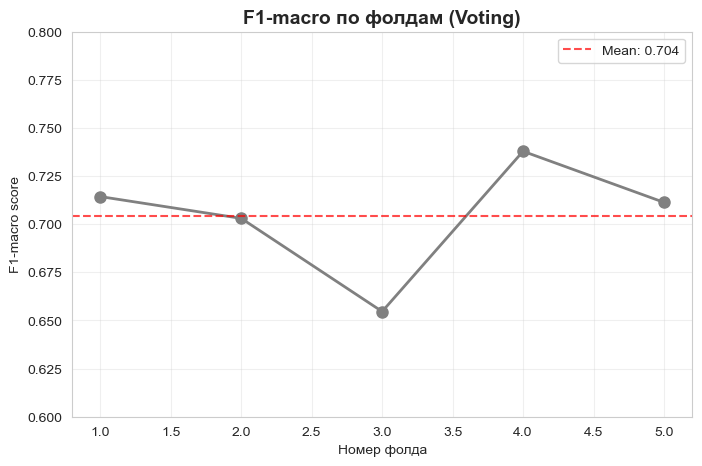

In [397]:
folds = np.arange(1, 6)

plt.figure(figsize=(8, 5))
plt.plot(folds, scores_vot, marker='o', linewidth=2, markersize=8, color='gray')
plt.axhline(y=np.mean(scores_vot), color='red', linestyle='--', alpha=0.7, label=f'Mean: {np.mean(scores_vot):.3f}')

plt.title('F1-macro по фолдам (Voting)', fontsize=14, fontweight='bold')
plt.xlabel('Номер фолда')
plt.ylabel('F1-macro score')
plt.ylim(0.6, 0.8)
plt.grid(True, alpha=0.3)
plt.legend()

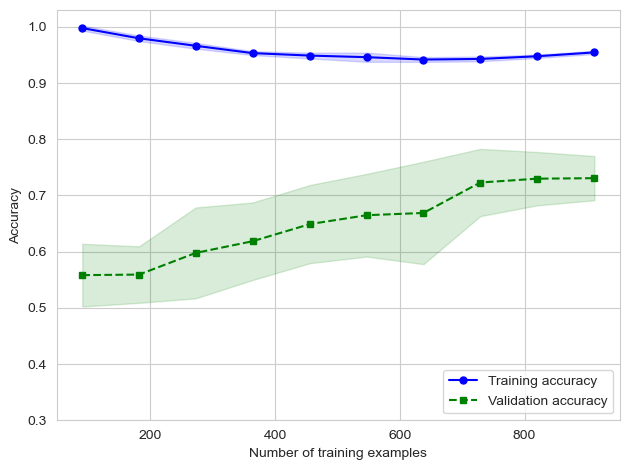

In [514]:
train_sizes, train_scores, test_scores =\
                learning_curve(estimator=voting_clf,
                               X=X_train_resampl,
                               y=y_train_resampl,
                               train_sizes=np.linspace(0.1, 1.0, 10),
                               cv=10,
                               n_jobs=-1)

train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

plt.plot(train_sizes, train_mean,
         color='blue', marker='o',
         markersize=5, label='Training accuracy')

plt.fill_between(train_sizes,
                 train_mean + train_std,
                 train_mean - train_std,
                 alpha=0.15, color='blue')

plt.plot(train_sizes, test_mean,
         color='green', linestyle='--',
         marker='s', markersize=5,
         label='Validation accuracy')

plt.fill_between(train_sizes,
                 test_mean + test_std,
                 test_mean - test_std,
                 alpha=0.15, color='green')

plt.grid()
plt.xlabel('Number of training examples')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.ylim([0.3, 1.03])
plt.tight_layout()
# plt.savefig('figures/06_05.png', dpi=300)
plt.show()

Мажоритарное голосование в нашем случае не особо помогло улучшить модели. Если проследить, то голосование стремится к метрикам KNN.

Переобучение

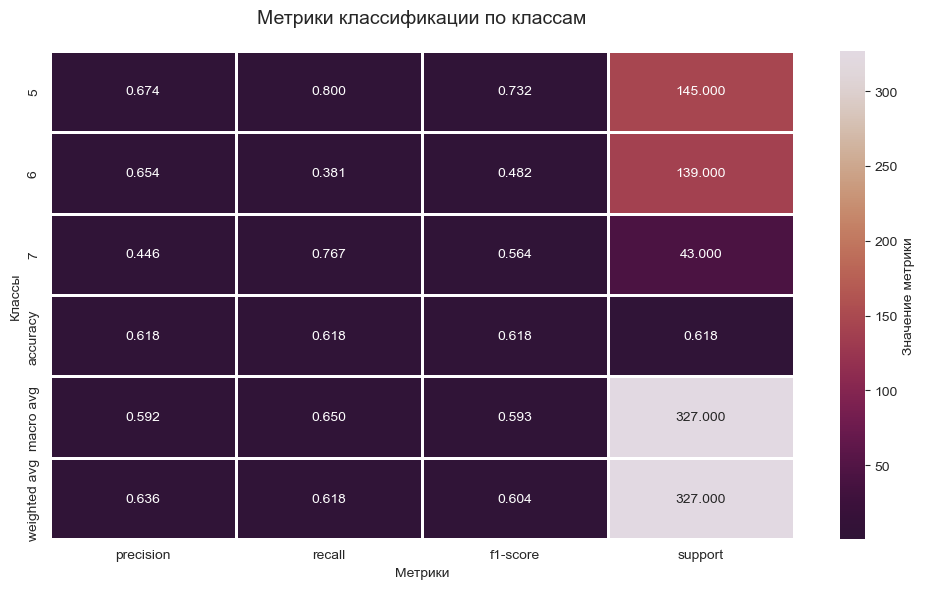

In [509]:
y_pred_vot = voting_clf.predict(X_test)

report_dict_vot = classification_report(y_test, y_pred_vot, output_dict=True)
metrics_df_vot = pd.DataFrame(report_dict_vot).transpose()

plt.figure(figsize=(10, 6))
sns.heatmap(metrics_df_vot, 
            annot=True, 
            fmt='.3f', 
            cmap='twilight',
            center=0.5,
            linewidths=1,
            cbar_kws={'label': 'Значение метрики'})

plt.title('Метрики классификации по классам', fontsize=14, pad=20)
plt.xlabel('Метрики')
plt.ylabel('Классы')
plt.tight_layout()
plt.show()

### Stack 

In [544]:
stacking_clf = StackingClassifier(
    estimators=[
        ('lr', lr),
        ('knn', knn_best),
        ('svc', svc_best)
    ],
    final_estimator=LogisticRegression(),
    cv=10  
)

stacking_clf.fit(X_train_resampl, y_train_resampl)
train_score_st = stacking_clf.score(X_train_resampl, y_train_resampl)
test_score_st = stacking_clf.score(X_test, y_test)
print((round(train_score_st, 2), round(test_score_st, 2)))

(1.0, 0.68)


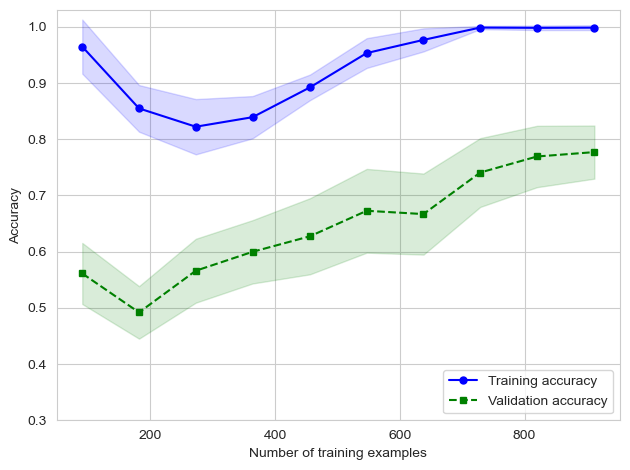

In [540]:
train_sizes, train_scores, test_scores =\
                learning_curve(estimator=stacking_clf,
                               X=X_train_resampl,
                               y=y_train_resampl,
                               train_sizes=np.linspace(0.1, 1.0, 10),
                               cv=10,
                               n_jobs=-1)

train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

plt.plot(train_sizes, train_mean,
         color='blue', marker='o',
         markersize=5, label='Training accuracy')

plt.fill_between(train_sizes,
                 train_mean + train_std,
                 train_mean - train_std,
                 alpha=0.15, color='blue')

plt.plot(train_sizes, test_mean,
         color='green', linestyle='--',
         marker='s', markersize=5,
         label='Validation accuracy')

plt.fill_between(train_sizes,
                 test_mean + test_std,
                 test_mean - test_std,
                 alpha=0.15, color='green')

plt.grid()
plt.xlabel('Number of training examples')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.ylim([0.3, 1.03])
plt.tight_layout()
plt.show()

Стеккинг улучшил голосование. Но также переобучен

# Вывод

1. ***LogisticRegression*** - многоклассовая классификация(multinomial), логистическая регрессия показала нам недообучение. С метриками - 0.65, 0.55(train, test)

============================================================================================================================================================================================================================

2. ***KNeighborsClassifier*** - ближайшие соседи показали переобучение. С метриками - 1.0, 0.6(train, test)

============================================================================================================================================================================================================================

3. ***SVC*** - классификатор на основе метода опорных векторов с ядровым трюком также показал переобучение. С метриками - 0.89, 0.56(train, test)

============================================================================================================================================================================================================================

5. ***VotingClassifier*** - мажоритарное голосование не улучшило ситуация, стремясь к KNN, переобучен. С метриками - 0.95, 0.62(train, test)

============================================================================================================================================================================================================================

7. ***StackingClassifier*** - стекинг напротив, смог улучшить базовые модели, и сформировал мета модель - LogisticRegression. Стоит развивать ход мыслей далее, по-прежнему есть переобучение. Метрики - 1.0, 0.68(train, test)


# Bonus

In [271]:
le = LabelEncoder()
y_train_resampl_encoded = le.fit_transform(y_train_resampl)
y_test_encoded = le.transform(y_test)

In [275]:
param_xgb = {
    'n_estimators': np.arange(50, 500, 100),
    'max_depth': np.arange(3, 100, 10),
    'learning_rate': np.linspace(0, 0.5, 10),
    'subsample': np.linspace(0.7, 0.3, 10),
    'colsample_bytree': np.linspace(0.7, 0.3, 10),
    'gamma': np.linspace(0, 5, 10),
    'reg_alpha': np.linspace(0, 2, 10),
    'reg_lambda': np.linspace(0, 2, 10)
}

xgb_clf = xgb.XGBClassifier(
    objective='multi:softprob',
    num_class=len(np.unique(y_train)),
    eval_metric='mlogloss',
    random_state=42,
    n_jobs=-1
)

hs_xgb = HalvingRandomSearchCV(
    estimator=xgb_clf,
    param_distributions=param_xgb,
    n_candidates=60,     
    cv=5,               
    factor=3,           
    random_state=42,
    n_jobs=-1,
    verbose=1
)

hs_xgb.fit(X_train_resampl, y_train_resampl_encoded)

print("Лучшие параметры:", hs_xgb.best_params_)
print("Лучший score:", hs_xgb.best_score_)

n_iterations: 4
n_required_iterations: 4
n_possible_iterations: 4
min_resources_: 30
max_resources_: 1014
aggressive_elimination: False
factor: 3
----------
iter: 0
n_candidates: 60
n_resources: 30
Fitting 5 folds for each of 60 candidates, totalling 300 fits
----------
iter: 1
n_candidates: 20
n_resources: 90
Fitting 5 folds for each of 20 candidates, totalling 100 fits
----------
iter: 2
n_candidates: 7
n_resources: 270
Fitting 5 folds for each of 7 candidates, totalling 35 fits
----------
iter: 3
n_candidates: 3
n_resources: 810
Fitting 5 folds for each of 3 candidates, totalling 15 fits
Лучшие параметры: {'subsample': 0.7, 'reg_lambda': 1.7777777777777777, 'reg_alpha': 1.7777777777777777, 'n_estimators': 350, 'max_depth': 83, 'learning_rate': 0.16666666666666666, 'gamma': 0.0, 'colsample_bytree': 0.5222222222222221}
Лучший score: 0.7095851545126907


In [490]:
xgb_best = hs_xgb.best_estimator_

train_score_xgb = xgb_best.score(X_train_resampl, y_train_resampl_encoded)
test_score_xgb = xgb_best.score(X_test, y_test_encoded)
print((round(train_score_xgb, 2), round(test_score_xgb, 2)))

(1.0, 0.6)
